<a href="https://colab.research.google.com/github/jorgeluisgonzalezjr/starbucks-nlp-sentiment-pipeline/blob/main/INFS_6359_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('starbucks_reviews_data.csv')

# Drop both 'name' and 'Image_Links' at the same time!
df.drop(columns=['name','Image_Links'], inplace=True)

print("Cleaned Dataset Columns:")
print(df.columns.tolist())

display(df.head())

Cleaned Dataset Columns:
['location', 'Date', 'Rating', 'Review']


,location,Date,Rating,Review
0,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...
1,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...
2,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...
3,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...
4,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...


In [ ]:
display(df.head())

,location,Date,Rating,Review
0,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...
1,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...
2,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...
3,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...
4,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...


## After cleaning up the data dropping the unnecessary columns the goal now is to tokenize our words/strings. Working with the idea of Text preprocessing. The practice of cleaning and preparing text data for machine learning algorithms.

## This projects falls into the Natural language Processing (NLP) Category,  helping machines understand and process human language in either text or audio form in this case we are using it to process text form


## The goal is build up those english words so that our machine learning model can read what is being passed in each review given .


## Reference: https://likegeeks.com/nlp-tutorial-using-python-nltk/

download necessary packages and librarys for this tokenization & lemmization



In [ ]:
import re
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt_tab') # chops sentences into tokens
nltk.download('wordnet') #lemmaization
nltk.download('averaged_perceptron_tagger') # tags speech
nltk.download('stopwords') #list of useless words we dont need
nltk.download('maxent_ne_chunker')
nltk.download('words')



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

Step 1 Tokenization : Chop up the sentences into individual words

In [ ]:
#where we will store text
list_of_tokens = []


#column of reviews
reviews = df['Review']
for review in reviews:
  review_string = str(review)
  #tokenizing text
  tokenized_text = word_tokenize(review_string)

  list_of_tokens.append(tokenized_text)

df['Tokenized_Words'] = list_of_tokens

display(df[['Review', 'Tokenized_Words']].head(3))

,Review,Tokenized_Words
0,Amber and LaDonna at the Starbucks on Southwes...,"[Amber, and, LaDonna, at, the, Starbucks, on, ..."
1,** at the Starbucks by the fire station on 436...,"[*, *, at, the, Starbucks, by, the, fire, stat..."
2,I just wanted to go out of my way to recognize...,"[I, just, wanted, to, go, out, of, my, way, to..."


## After tokenization we can move onto the next step which is stop words...


## stop words are important to take from this project so that the model doesnt focus on words such as 'the' 'and' or 'is'. The point is to do a sentiment analysis on these reviews

In [ ]:
from nltk.corpus import stopwords

#  stop words
stop_words_list = set(stopwords.words('english'))

# empty array for our clean text
cleaned_reviews_list = []

# Loop through your newly created Tokenized_Words column
for tokens in df['Tokenized_Words']:

    # Temporary array for the current review
    filtered_tokens = []

    for word in tokens:
        # Make the words lowercase
        lower_word = word.lower()

        # .isalpha() checks if it's a real word (drops punctuation and numbers)
        # Check if it's NOT in our stop words list
        if lower_word.isalpha() and lower_word not in stop_words_list:
            filtered_tokens.append(lower_word)

    # Add the cleaned words to our main array
    cleaned_reviews_list.append(filtered_tokens)

# 4. Attach it back to the dataframe
df['Cleaned_Tokens'] = cleaned_reviews_list

# Let's see the magic
display(df[['Tokenized_Words', 'Cleaned_Tokens']].head(3))

,Tokenized_Words,Cleaned_Tokens
0,"[Amber, and, LaDonna, at, the, Starbucks, on, ...","[amber, ladonna, starbucks, southwest, parkway..."
1,"[*, *, at, the, Starbucks, by, the, fire, stat...","[starbucks, fire, station, altamonte, springs,..."
2,"[I, just, wanted, to, go, out, of, my, way, to...","[wanted, go, way, recognize, starbucks, employ..."


#Step 4: Lemmatization - Converting words to their real dictionary roots



## Before we can transition our text into the numerical embeddings required by our LSTM, we must reduce our cleaned words down to their core dictionary roots. To achieve this, we are utilizing **Lemmatization** rather than traditional Stemming.

## **Lemmatization preserves exact meaning:** Lemmatization utilizes a comprehensive linguistic dictionary (WordNet) to accurately convert words back to their grammatical roots (e.g., accurately turning "happily" into "happy", or "spilled" into "spill").

## By converting all variations of a word into a single root form, we drastically reduce the total number of unique words (the vocabulary size) our neural network has to learn. This minimizes memory overhead, speeds up the training time of our LSTM, and ensures that our unsupervised LDA model clusters themes much more efficiently.

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

nltk.download("omw-1.4")

#Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

#Create an empty array for the final processed words
final_lemmatized_list = []

# Loop through your cleaned tokens
for token_list in df['Cleaned_Tokens']:

    # Use the exact list comprehension you found to lemmatize the current review
    lemmatized_words = [lemmatizer.lemmatize(word) for word in token_list]

    # Add to our main array
    final_lemmatized_list.append(lemmatized_words)

# 4. Attach it back to the dataframe
df['Lemmatized_Tokens'] = final_lemmatized_list

# Let's see the final Phase 1 output!
display(df[['Cleaned_Tokens', 'Lemmatized_Tokens']].head(3))

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Cleaned_Tokens,Lemmatized_Tokens
0,"[amber, ladonna, starbucks, southwest, parkway...","[amber, ladonna, starbucks, southwest, parkway..."
1,"[starbucks, fire, station, altamonte, springs,...","[starbucks, fire, station, altamonte, spring, ..."
2,"[wanted, go, way, recognize, starbucks, employ...","[wanted, go, way, recognize, starbucks, employ..."


## Hypothesis: The better reviews a starbucks has is because of the better education the location has we use this data from kaggle to work this out


## https://www.kaggle.com/datasets/rishidamarla/colleges-and-universities-in-the-us

In [ ]:
import pandas as pd

# 1. Load the new, much better Universities dataset!
# (Make sure 'Colleges_and_Universities.csv' is uploaded to your Colab session)
college_df = pd.read_csv('Colleges_and_Universities.csv')

# 2. Keep only the columns we need as you suggested
college_df = college_df[['NAME', 'CITY', 'STATE']].copy()

# 3. Clean up the text (removes weird spaces, Title Cases the city, and Uppers the state)
college_df['CITY'] = college_df['CITY'].astype(str).str.strip().str.title()
college_df['STATE'] = college_df['STATE'].astype(str).str.strip().str.upper()

# 4. Create the magical 'location' column to match our Starbucks dataset (e.g., "Austin, TX")
college_df['location'] = college_df['CITY'] + ", " + college_df['STATE']

# 5. Extract a list of all unique college town locations
college_town_locations = college_df['location'].unique()

# 6. Flag our Starbucks dataset! (If the Starbucks city is in the college list, it gets a True)
df['Is_College_Town'] = df['location'].isin(college_town_locations)

# 7. Let's run the Hypothesis Test with the REAL data!
df_rated = df.dropna(subset=['Rating']).copy()

hypothesis_test = df_rated.groupby('Is_College_Town').agg(
    Average_Rating=('Rating', 'mean'),
    Total_Reviews=('Rating', 'count')
).reset_index()

# Make it look nice for the presentation
hypothesis_test['Is_College_Town'] = hypothesis_test['Is_College_Town'].map({
    True: 'Yes (College Town)',
    False: 'No (Regular Location)'
})

print("--- REAL HYPOTHESIS TEST RESULTS ---")
display(hypothesis_test)

# Check out our new merged feature!
display(df[['location', 'Rating', 'Is_College_Town']].head(10))

--- REAL HYPOTHESIS TEST RESULTS ---


,Is_College_Town,Average_Rating,Total_Reviews
0,No (Regular Location),1.992883,281
1,Yes (College Town),1.790094,424


,location,Rating,Is_College_Town
0,"Wichita Falls, TX",5.0,True
1,"Apopka, FL",5.0,True
2,"Cranberry Twp, PA",5.0,False
3,"Seattle, WA",5.0,True
4,"Gresham, OR",5.0,True
5,"Sunnyvale, TX",1.0,False
6,"Spring Hill, FL",1.0,True
7,"Asheville, NC",1.0,True
8,"Reisterstown, MD",1.0,True
9,"Zionville, Other",1.0,False


To fulfill the requirement of utilizing unsupervised learning, we are implementing a **Latent Dirichlet Allocation (LDA)** model using the Gensim library.

Instead of manually guessing what customers are talking about, this algorithm scans the mathematical frequencies of our `Lemmatized_Tokens` to discover hidden themes (topics) automatically. Once these topics are discovered, we will cross-reference them with our new `Is_College_Town` feature to uncover geographical business insights.

In [ ]:
!pip install gensim

In [ ]:

import gensim
import gensim.corpora as corpora

# Make sure we drop any blank rows just to be safe
df_lda = df.dropna(subset=['Lemmatized_Tokens']).copy()

# --- PART 1: PREPPING THE DATA FOR GENSIM ---

# 1. Create a Dictionary (This gives every unique lemmatized word an ID number)
id2word = corpora.Dictionary(df_lda['Lemmatized_Tokens'])

# Filter out extreme words (Words that appear in less than 2 reviews, or in over 50% of them)
# This gets rid of useless words that snuck through, like "starbucks" or "coffee"
id2word.filter_extremes(no_below=2, no_above=0.5)

# 2. Create the Corpus (Bag of Words)
# This translates your words into math: (Word_ID, Word_Frequency)
texts = df_lda['Lemmatized_Tokens'].tolist()
corpus = [id2word.doc2bow(text) for text in texts]


# --- PART 2: TRAINING THE UNSUPERVISED MODEL ---

# We are telling the algorithm to look for 4 distinct hidden themes
num_topics = 4

print("Training LDA Model... This might take a few seconds.")
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=num_topics,
                                           random_state=100,
                                           passes=10, # Loops through the data 10 times to learn
                                           alpha='auto')

# Print out the hidden topics it discovered
print("\n--- Unsupervised Topics Discovered ---")
for idx, topic in lda_model.print_topics(-1):
    print(f"\nTopic {idx}: \nKeywords: {topic}")

Training LDA Model... This might take a few seconds.

--- Unsupervised Topics Discovered ---

Topic 0: 
Keywords: 0.024*"card" + 0.016*"customer" + 0.013*"coffee" + 0.013*"store" + 0.009*"service" + 0.008*"said" + 0.008*"get" + 0.008*"day" + 0.008*"time" + 0.007*"go"

Topic 1: 
Keywords: 0.024*"customer" + 0.020*"service" + 0.012*"order" + 0.011*"time" + 0.010*"store" + 0.009*"get" + 0.008*"said" + 0.007*"drink" + 0.007*"coffee" + 0.007*"like"

Topic 2: 
Keywords: 0.012*"coffee" + 0.012*"customer" + 0.012*"drink" + 0.011*"time" + 0.011*"one" + 0.008*"get" + 0.008*"employee" + 0.007*"like" + 0.007*"store" + 0.006*"never"

Topic 3: 
Keywords: 0.031*"coffee" + 0.018*"drink" + 0.010*"ordered" + 0.010*"one" + 0.010*"time" + 0.010*"cup" + 0.009*"go" + 0.008*"get" + 0.008*"would" + 0.008*"went"


[link text](https://)Topic interpretation:
* Topic 0 -> Payment & Rewards Transactions
* Topic 1 -> Customer Service & Wait Times (
* Topic 2 -> Staff Behavior & Environment (
* Topic 3 -> Product Quality & Order Accuracy

In [ ]:
# TYING TOPICS TO COLLEGE TOWNS

dominant_topics = []

# Loop through every review's math frequencies
for bag_of_words in corpus:
    # Get the topic probabilities for the current review
    topic_probs = lda_model.get_document_topics(bag_of_words)

    # Find the topic with the highest percentage/probability
    best_topic = max(topic_probs, key=lambda x: x[1])[0]
    dominant_topics.append(best_topic)

# Add the Dominant Topic as a new column
df_lda['Dominant_Topic'] = dominant_topics

# Group the data to see what College Towns care about vs Regular Locations!
business_insight = df_lda.groupby(['Is_College_Town', 'Dominant_Topic']).size().unstack(fill_value=0)

print("--- TOPIC BREAKDOWN: COLLEGE TOWNS VS REGULAR LOCATIONS ---")
display(business_insight)

--- TOPIC BREAKDOWN: COLLEGE TOWNS VS REGULAR LOCATIONS ---


Dominant_Topic,0,1,2,3
Is_College_Town,,,,
False,93,63,57,138
True,147,77,109,166


In [ ]:
# --- TYING TOPICS TO SENTIMENT ---

#Question: Here's what causes positive vs negative experiences

# Make sure sentiment exists (reuse your LSTM labeling logic)
df_lda['Sentiment'] = df_lda['Rating'].apply(lambda x: 1 if x >= 4 else 0)

# Group topics by sentiment
sentiment_insight = df_lda.groupby(['Sentiment', 'Dominant_Topic']).size().unstack(fill_value=0)

print("--- TOPIC BREAKDOWN: POSITIVE VS NEGATIVE REVIEWS ---")
display(sentiment_insight)

--- TOPIC BREAKDOWN: POSITIVE VS NEGATIVE REVIEWS ---


Dominant_Topic,0,1,2,3
Sentiment,,,,
0,195,126,133,274
1,45,14,33,30


We can now combine both analyses that will help us answer questions like the following:
Do college towns complain about different things?
Are certain topics more negative in specific areas?

In [ ]:
#COMBINING BOTH ANALYSES
combined_insight = df_lda.groupby(
    ['Is_College_Town', 'Sentiment', 'Dominant_Topic']
).size()

print("--- LOCATION + SENTIMENT + TOPIC ---")
print(combined_insight)

--- LOCATION + SENTIMENT + TOPIC ---
Is_College_Town  Sentiment  Dominant_Topic
False            0          0                  75
                            1                  57
                            2                  43
                            3                 119
                 1          0                  18
                            1                   6
                            2                  14
                            3                  19
True             0          0                 120
                            1                  69
                            2                  90
                            3                 155
                 1          0                  27
                            1                   8
                            2                  19
                            3                  11
dtype: int64


Key Findings:
* Topic 3 has the biggest complaint
* Topic 0 and 2 are the most problematic especially in college towns
* Positive reviews are weaker and less consistent

## Step 7: Word Embeddings (Word2Vec)
Neural networks like LSTMs cannot process raw text. To solve this, we are training a **Word2Vec** model to translate our `Lemmatized_Tokens` into dense numerical vectors.

By doing this, the model learns the semantic context of our dataset. It will mathematically understand that words like "barista" and "employee" are closely related, or that "slow" and "wait" share a similar negative context. This embedded matrix will serve as the input layer for our final Deep Learning architecture.

In [ ]:
from gensim.models import Word2Vec

# 1. Grab the clean, lemmatized lists of words from our dataframe
# Word2Vec expects a list of lists: [['coffee', 'good'], ['wait', 'long', 'bad']]
sentences = df['Lemmatized_Tokens'].tolist()

print("Training Word2Vec Model...")

# 2. Build and train the Word2Vec model
# vector_size = 100: Every word is translated into an array of 100 numbers
# window = 5: The model looks at 5 words before and after a word to learn its context
# min_count = 2: Ignores words that only appear once in the entire dataset
w2v_model = Word2Vec(sentences=sentences,
                     vector_size=100,
                     window=5,
                     min_count=2,
                     workers=4) # Uses 4 CPU cores to train faster

print("Word2Vec Model Trained Successfully!")

# 3. Let's test it out!
# We can ask the model what words are mathematically most similar to "coffee"
test_word = 'coffee'

# We use a try-except block just in case the test word got filtered out earlier
try:
    similar_words = w2v_model.wv.most_similar(test_word, topn=5)
    print(f"\nWords most mathematically similar to '{test_word}':")
    for word, similarity_score in similar_words:
        print(f"- {word} (Score: {similarity_score:.4f})")
except KeyError:
    print(f"\nThe word '{test_word}' is not in the vocabulary.")

# 4. (Optional) See the actual math!
# Uncomment the line below if you want to see the 100 numbers that represent "coffee"
# print(w2v_model.wv['coffee'])

Training Word2Vec Model...
Word2Vec Model Trained Successfully!

Words most mathematically similar to 'coffee':
- starbucks (Score: 0.9999)
- employee (Score: 0.9999)
- location (Score: 0.9999)
- also (Score: 0.9999)
- drink (Score: 0.9999)


## Step 8: Visualizing the Data (Word Cloud)
Before building our Deep Learning model, we want to visually summarize the overarching sentiment of our entire dataset.

By generating a Word Cloud from our `Lemmatized_Tokens`, we can instantly communicate the most frequent topics and concerns to business stakeholders without requiring them to parse through raw data or complex mathematical models. The larger the word appears, the more frequently it was mentioned across all Starbucks locations.

Generating Word Cloud...


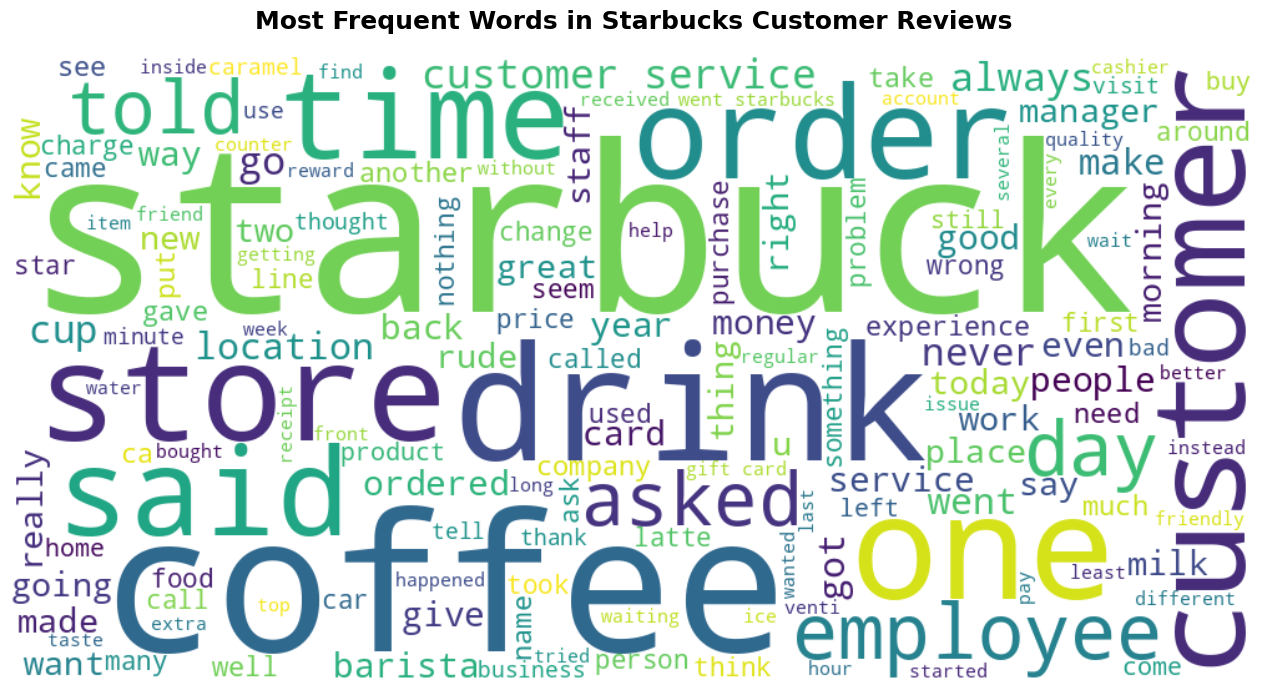

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. We need to take all the individual words from our Lemmatized_Tokens column
# and combine them into one massive string of text.
all_words_list = []

# Make sure we drop any blank rows just to be safe
df_wc = df.dropna(subset=['Lemmatized_Tokens']).copy()

for token_list in df_wc['Lemmatized_Tokens']:
    # .extend() adds all the words from the current review into our master list
    all_words_list.extend(token_list)

# Join the thousands of words together separated by a space
giant_text_string = ' '.join(all_words_list)

# 2. Build the Word Cloud object
print("Generating Word Cloud...")
wordcloud = WordCloud(width=1000,
                      height=500,
                      background_color='white',
                      colormap='viridis', # 'viridis', 'plasma', 'inferno', 'magma', or 'cividis' are great options!
                      max_words=150).generate(giant_text_string)

# 3. Plot the Word Cloud using matplotlib
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Hides the x and y axis grids so it looks like a clean image
plt.title('Most Frequent Words in Starbucks Customer Reviews', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()

# Just add a list of words you want to ignore inside the WordCloud function!
wordcloud = WordCloud(width=1000,
                      height=500,
                      background_color='white',
                      stopwords=['starbucks', 'coffee', 'drink', 'order'], # <--- ADD THIS
                      max_words=150).generate(giant_text_string)
# Show the masterpiece
plt.show()

## Step 9: Predictive Sentiment Analysis using LSTM
With our text preprocessed and our unsupervised business insights extracted, we now transition to Supervised Deep Learning.

We are building a **Long Short-Term Memory (LSTM)** neural network. Unlike standard models, LSTMs have an internal "memory" mechanism that allows them to understand the sequence and context of words in a sentence (e.g., understanding that "not good" is negative, even though the word "good" is present).

We will convert our 1-5 Star Ratings into binary Sentiment (1 = Positive, 0 = Negative), pad our text sequences to a uniform length, and train the model to predict the sentiment of unseen reviews.

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# 1. Drop any rows that don't have a Rating
df_lstm = df.dropna(subset=['Rating', 'Lemmatized_Tokens']).copy()

# 2. Convert Star Ratings to Binary Sentiment
# Let's say 4 and 5 stars are Positive (1). 1, 2, and 3 stars are Negative (0).
df_lstm['Sentiment'] = df_lstm['Rating'].apply(lambda x: 1 if x >= 4 else 0)

# 3. Keras Tokenizer (Converts your clean words into mathematical sequences)
# We recreate the dictionary specifically for the neural network
max_words = 5000 # The top 5,000 most common words in your dataset
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df_lstm['Lemmatized_Tokens'])

# Translate the words to sequences of numbers
X_sequences = tokenizer.texts_to_sequences(df_lstm['Lemmatized_Tokens'])

# 4. Padding!
# Make every review exactly 50 words long (pads with zeros if too short, cuts off if too long)
max_sequence_length = 50
X_padded = pad_sequences(X_sequences, maxlen=max_sequence_length)

# 5. Define our 'Y' (The answers we want the model to learn)
Y = df_lstm['Sentiment'].values

# 6. Train/Test Split (80% of data to learn, 20% to test itself)
X_train, X_test, Y_train, Y_test = train_test_split(X_padded, Y, test_size=0.2, random_state=42)

print(f"Data prepped! Training on {len(X_train)} reviews, Testing on {len(X_test)} reviews.")

Data prepped! Training on 564 reviews, Testing on 141 reviews.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# --- PART 1: BUILD THE ARCHITECTURE ---
print("Building LSTM Architecture...")

model = Sequential()

# Layer 1: The Embedding Layer (The mathematical translation layer)
model.add(Embedding(input_dim=max_words, output_dim=100, input_length=max_sequence_length))

# Layer 2: The LSTM Layer (The brain of the operation)
# 64 memory units, dropout prevents the model from just memorizing the answers
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))

# Layer 3: The Output Layer
# A Dense layer with 1 node and 'sigmoid' activation gives us a percentage score (0% to 100% positive)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(model.summary())

# --- PART 2: TRAIN THE MODEL ---
print("\nStarting Training...")

# epochs=5: It will study your flashcards (data) 5 times over.
# batch_size=32: It will look at 32 reviews at a time before updating its math.
history = model.fit(X_train, Y_train,
                    epochs=5,
                    batch_size=32,
                    validation_data=(X_test, Y_test))

# --- PART 3: TEST THE ACCURACY ---
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"\n🏆 Final AI Model Accuracy: {accuracy * 100:.2f}%")

Building LSTM Architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None

Starting Training...
Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 159ms/step - accuracy: 0.8067 - loss: 0.6103 - val_accuracy: 0.7872 - val_loss: 0.5413
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.8564 - loss: 0.3623 - val_accuracy: 0.8156 - val_loss: 0.4613
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.8901 - loss: 0.2705 - val_accuracy: 0.8582 - val_loss: 0.3884
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9468 - loss: 0.1717 - val_accuracy: 0.8936 - val_loss: 0.3569
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9805 - loss: 0.0850 - val_accuracy: 0.8936 - val_loss: 0.3931
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8936 - loss: 0.3931

🏆 Final AI Model Accuracy: 89.36%


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 505ms/step
🏆 Final Model Accuracy: 89.36%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       111
           1       0.86      0.60      0.71        30

    accuracy                           0.89       141
   macro avg       0.88      0.79      0.82       141
weighted avg       0.89      0.89      0.89       141



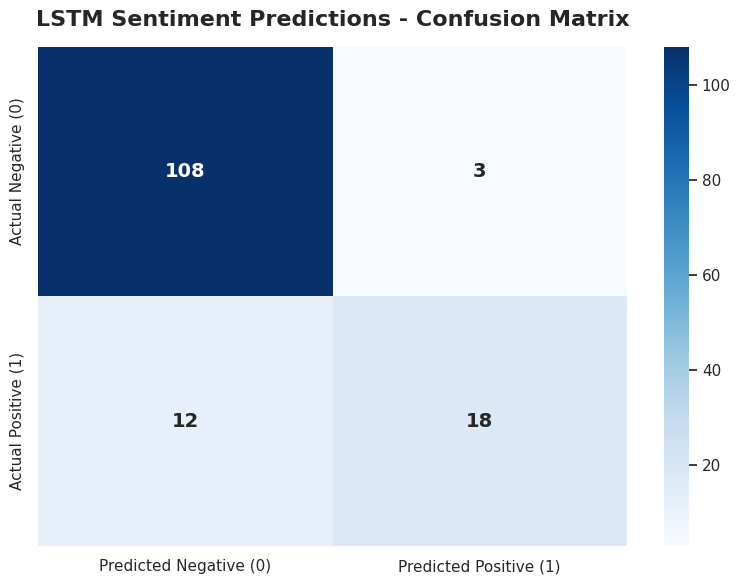

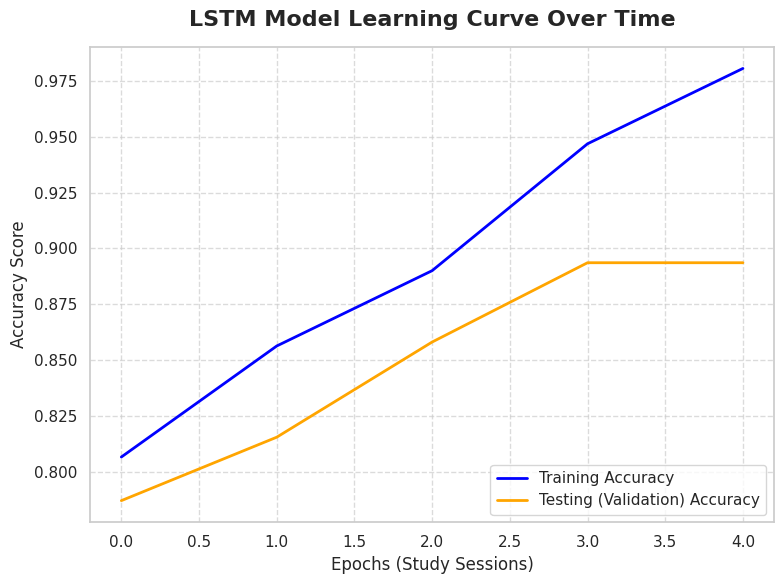

In [ ]:
# --- LSTM Evaluation & Visualizations ---
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict sentiment from LSTM (Translates probabilities back to 1s and 0s)
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# 1. Print the Core Accuracy
accuracy = accuracy_score(Y_test, y_pred)
print(f"🏆 Final Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(Y_test, y_pred))

# 2. Visual Confusion Matrix (The Heatmap)
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('LSTM Sentiment Predictions - Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 3. Visual Training History (Did the model actually learn?)
# This graphs the 'history' variable from when you trained the model
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Testing (Validation) Accuracy', color='orange', linewidth=2)

plt.title('LSTM Model Learning Curve Over Time', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs (Study Sessions)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/tmp/ipykernel_855/4043779161.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Is_College_Town', y='Average_Rating', data=hypothesis_test, palette='Blues_d')


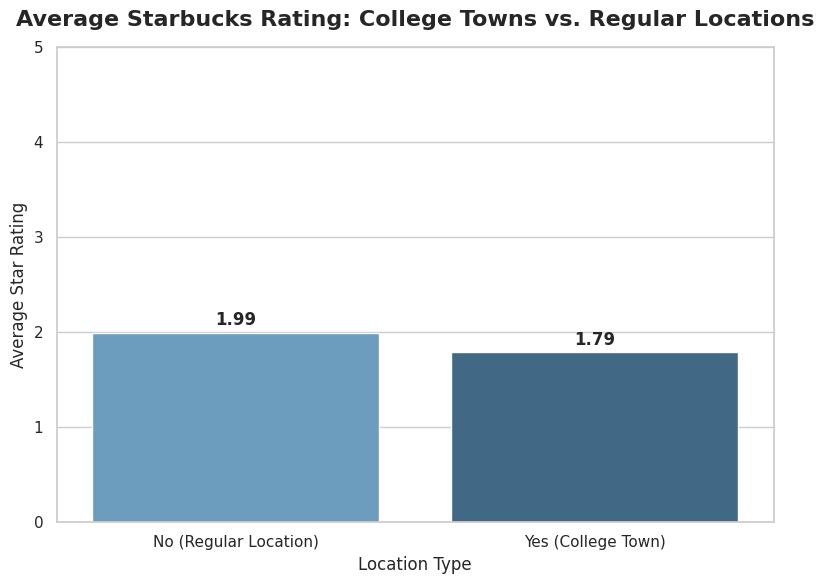


--- Our Enriched Dataset (Notice the new University_Name column!) ---


,location,University_Name,Is_College_Town
0,"Wichita Falls, TX",Midwestern State University,Yes (College Town)
1,"Apopka, FL",Hair Design Institute,Yes (College Town)
2,"Cranberry Twp, PA",NaN,No (Regular Location)
3,"Seattle, WA",GP Institute of Cosmetology,Yes (College Town)
4,"Gresham, OR",Mt Hood Community College,Yes (College Town)
5,"Sunnyvale, TX",NaN,No (Regular Location)
6,"Spring Hill, FL",ATA Career Education,Yes (College Town)
7,"Asheville, NC",Carolina College of Hair Design,Yes (College Town)
8,"Reisterstown, MD",Maryland Beauty Academy,Yes (College Town)
9,"Zionville, Other",NaN,No (Regular Location)


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. THE TRUE DATA MERGE ---
# Load the Universities dataset
college_df = pd.read_csv('Colleges_and_Universities.csv')
college_df = college_df[['NAME', 'CITY', 'STATE']].copy()

# Clean it up to match our Starbucks data
college_df['CITY'] = college_df['CITY'].astype(str).str.strip().str.title()
college_df['STATE'] = college_df['STATE'].astype(str).str.strip().str.upper()
college_df['location'] = college_df['CITY'] + ", " + college_df['STATE']

# Drop duplicate cities in the college dataset so the merge is clean
college_df_unique = college_df.drop_duplicates(subset=['location'])

# THE MERGE! We attach the University 'NAME' to our Starbucks dataframe based on 'location'
df = pd.merge(df, college_df_unique[['location', 'NAME']], on='location', how='left')

# Rename the column so it looks professional
df.rename(columns={'NAME': 'University_Name'}, inplace=True)

# Create the presentation labels based on if a University Name attached successfully
df['Is_College_Town'] = df['University_Name'].notna().map({
    True: 'Yes (College Town)',
    False: 'No (Regular Location)'
})


# --- 2. CALCULATING THE STATS ---
# Build the hypothesis_test dataframe for the chart
df_rated = df.dropna(subset=['Rating']).copy()
hypothesis_test = df_rated.groupby('Is_College_Town').agg(
    Average_Rating=('Rating', 'mean'),
    Total_Reviews=('Rating', 'count')
).reset_index()


# --- 3. GENERATING THE PRESENTATION CHART ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Plot the chart using our newly merged data
ax = sns.barplot(x='Is_College_Town', y='Average_Rating', data=hypothesis_test, palette='Blues_d')

plt.title('Average Starbucks Rating: College Towns vs. Regular Locations', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Location Type', fontsize=12)
plt.ylabel('Average Star Rating', fontsize=12)
plt.ylim(0, 5)

# Add the exact numbers on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Let's peek at the newly merged dataframe to prove it worked!
print("\n--- Our Enriched Dataset (Notice the new University_Name column!) ---")
display(df[['location', 'University_Name', 'Is_College_Town']].head(10))

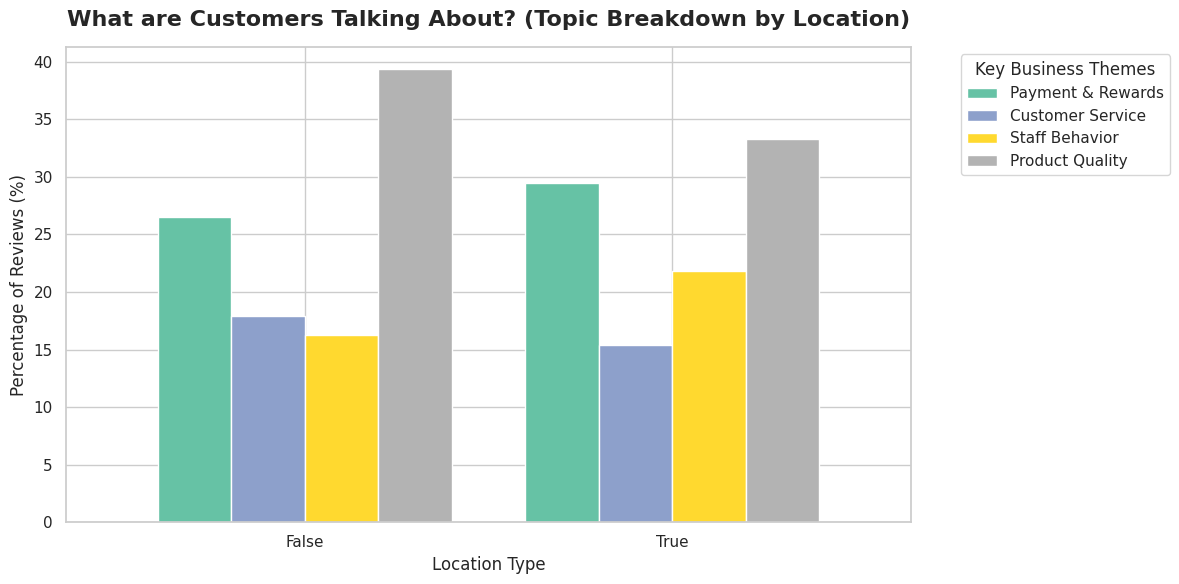

In [ ]:
# Rename the topics from numbers to our professional Business Labels!
business_insight.columns = [
    'Payment & Rewards',
    'Customer Service',
    'Staff Behavior',
    'Product Quality'
]

# Now, recalculate the percentages and plot the chart!
topic_pct = business_insight.div(business_insight.sum(axis=1), axis=0) * 100
ax = topic_pct.plot(kind='bar', figsize=(12, 6), colormap='Set2', width=0.8)

# Format it for the presentation
import matplotlib.pyplot as plt
plt.title('What are Customers Talking About? (Topic Breakdown by Location)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Location Type', fontsize=12)
plt.ylabel('Percentage of Reviews (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Key Business Themes', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#Evaluation

In [ ]:
#LSTM Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict sentiment from LSTM
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Accuracy
accuracy = accuracy_score(Y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Precision / Recall / F1
print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Model Accuracy: 0.8936

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       111
           1       0.86      0.60      0.71        30

    accuracy                           0.89       141
   macro avg       0.88      0.79      0.82       141
weighted avg       0.89      0.89      0.89       141


Confusion Matrix:
[[108   3]
 [ 12  18]]


To evaluate quality of the topics generated by the LDA model, we used two standard metrics: coherence score and preplexity. Coherence measures how semantically consistent the words are within each topic are. Perplexity measures how well the model predictes the distribution of words in the dataset.

In [ ]:
#Topic Coherence - Evaluation Metric for LDA
from gensim.models import CoherenceModel

coherence_model_lda = CoherenceModel(
    model=lda_model,
    texts=texts,        # your tokenized text data
    dictionary=id2word,
    coherence='c_v'
)

coherence_score = coherence_model_lda.get_coherence()

print("\n--- LDA Evaluation ---")
print(f"Coherence Score: {coherence_score:.4f}")

#.50 -> Decent Topics

print(f"Perplexity: {lda_model.log_perplexity(corpus):.4f}")


--- LDA Evaluation ---
Coherence Score: 0.4248
Perplexity: -7.0667


To increase the coherence score we could try increasing the num_topics from 4 to 6,8, or 9 in the training portion.